# Techincal Requirements
## Part A: Data Preprocessing Pipeline

Covers all 4 spec requirements:
1.  Text cleaning (imported from EDA)
2.  Tokenisation & vocabulary construction
3.  Encoding & padding
4.  Dataset splitting (70/10/20 stratified)

## 0. Imports and Constants

In [1]:
import re
import torch
from collections import Counter
from torch.utils.data import Dataset, DataLoader, Subset
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# Special token indices
PAD, UNK = 0, 1

# ── Hyperparameters to experiment with (spec says N ∈ {10000, 20000, 30000}) ──
MAX_VOCAB_SIZE = 20_000   # try 10_000 / 20_000 / 30_000
MAX_LEN        = 454      # from EDA p90; try 128 / 256 / 512
BATCH_SIZE     = 64
SEED           = 42

print(f'Config: vocab={MAX_VOCAB_SIZE:,}  max_len={MAX_LEN}  batch={BATCH_SIZE}')

d:\JupyterEnvs\my_new_kernel_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Config: vocab=20,000  max_len=454  batch=64


## 1. Text Cleaning (Reused from 01_eda.ipynb)

In [2]:
def clean_text(text: str) -> str:
    """Remove HTML tags, keep only letters/digits/spaces, lowercase."""
    text = re.sub(r'<[^>]+>', ' ', text)          # strip HTML tags
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)   # keep letters & digits only
    return text.lower().strip()

# ── Load & clean IMDb ──────────────────────────────────────────────────────────
dataset = load_dataset('imdb')

# Combine train + test so we can do our own 70/10/20 split
all_texts  = ([clean_text(ex['text']) for ex in dataset['train']] +
              [clean_text(ex['text']) for ex in dataset['test']])
all_labels = ([ex['label'] for ex in dataset['train']] +
              [ex['label'] for ex in dataset['test']])

print(f'Total samples after cleaning: {len(all_texts):,}')
print(f'Sample: "{all_texts[0][:120]}..."')

Total samples after cleaning: 50,000
Sample: "i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first rel..."


## 2. Tokenisation and vocabulary construction 

In [3]:
def build_vocab(texts: list[str], max_size: int = 20_000) -> dict[str, int]:
    """
    Build word→index vocabulary from a list of cleaned texts.
    Reserves index 0 for <pad> and index 1 for <unk>.
    Returns the top (max_size - 2) most frequent tokens.
    """
    counter = Counter(w for text in texts for w in text.split())
    vocab   = {'<pad>': PAD, '<unk>': UNK}
    for word, _ in counter.most_common(max_size - 2):
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(all_texts, max_size=MAX_VOCAB_SIZE)

print(f'Vocabulary size : {len(vocab):,}  (including <pad> and <unk>)')
print(f'Top-10 entries  : {list(vocab.items())[2:12]}')

Vocabulary size : 20,000  (including <pad> and <unk>)
Top-10 entries  : [('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('it', 8), ('in', 9), ('i', 10), ('this', 11)]


### Note: Stopwords Retained

Stopwords are kept for two reasons:
1. **RNN compatibility:** Sequential models rely on word order — removing
words like "not" can flip sentiment (e.g. "not bad" → "bad").
2. **Vocab cap handles noise:** The 20k limit naturally deprioritises low-signal
tokens; their embeddings will converge to near-zero during training.

## 3. Encoding and padding

In [4]:
class SentimentDataset(Dataset):
    """
    PyTorch Dataset for IMDb sentiment.
    Encodes text → integer IDs and truncates to max_len at construction time.
    Padding to a uniform length within each batch is handled by collate_fn.
    """

    def __init__(self, texts: list[str], labels: list[int],
                 vocab: dict[str, int], max_len: int = 256):
        self.data = []
        for text, label in zip(texts, labels):
            ids = [vocab.get(w, UNK) for w in text.split()]  # encode
            ids = ids[:max_len]                               # truncate if too long
            self.data.append((
                torch.tensor(ids,   dtype=torch.long),
                torch.tensor(label, dtype=torch.long)
            ))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        return self.data[i]


def collate_fn(batch):
    """
    Dynamic batch padding: pads all sequences in the batch to the length
    of the longest sequence in that batch (not the global max_len).
    This avoids wasting compute on excessive padding for short-review batches.
    """
    seqs, labels = zip(*batch)
    seqs_padded  = pad_sequence(seqs, batch_first=True, padding_value=PAD)
    return seqs_padded, torch.stack(labels)


# Quick encode sanity check
sample_ids = [vocab.get(w, UNK) for w in all_texts[0].split()][:10]
print('First 10 token IDs of sample[0]:', sample_ids)
print('Decoded back                    :', [list(vocab.keys())[list(vocab.values()).index(i)] for i in sample_ids])

First 10 token IDs of sample[0]: [10, 1568, 10, 236, 2114, 3832, 38, 59, 374, 1073]
Decoded back                    : ['i', 'rented', 'i', 'am', 'curious', 'yellow', 'from', 'my', 'video', 'store']


## 4. Dataset splitting

In [5]:
from sklearn.model_selection import train_test_split

indices = list(range(len(all_texts)))

# Step 1: split off 20% test
idx_trainval, idx_test = train_test_split(
    indices, test_size=0.20, stratify=all_labels, random_state=SEED
)

# Step 2: split remaining 80% into 70% train + 10% val
# 10% of total = 10/80 = 12.5% of trainval
labels_trainval = [all_labels[i] for i in idx_trainval]
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.125, stratify=labels_trainval, random_state=SEED
)

# Verify split sizes
total = len(all_texts)
print(f'Total  : {total:,}')
print(f'Train  : {len(idx_train):,}  ({len(idx_train)/total*100:.1f}%)')
print(f'Val    : {len(idx_val):,}   ({len(idx_val)/total*100:.1f}%)')
print(f'Test   : {len(idx_test):,}  ({len(idx_test)/total*100:.1f}%)')

# Verify class balance is preserved
for name, idx_split in [('Train', idx_train), ('Val', idx_val), ('Test', idx_test)]:
    labels_split = [all_labels[i] for i in idx_split]
    pos_pct = sum(labels_split) / len(labels_split) * 100
    print(f'  {name} positive ratio: {pos_pct:.1f}%')

Total  : 50,000
Train  : 35,000  (70.0%)
Val    : 5,000   (10.0%)
Test   : 10,000  (20.0%)
  Train positive ratio: 50.0%
  Val positive ratio: 50.0%
  Test positive ratio: 50.0%


## 5. Build Dataset & DataLoader Objects

In [6]:
# Build the full dataset once, then slice by split indices
full_dataset = SentimentDataset(all_texts, all_labels, vocab, max_len=MAX_LEN)

train_dataset = Subset(full_dataset, idx_train)
val_dataset   = Subset(full_dataset, idx_val)
test_dataset  = Subset(full_dataset, idx_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Inspect a single batch
batch_seqs, batch_labels = next(iter(train_loader))
print(f'Batch seq shape : {batch_seqs.shape}   (batch_size × padded_len)')
print(f'Batch label shape: {batch_labels.shape}')
print(f'Longest seq in this batch: {batch_seqs.shape[1]} tokens  (dynamic padding in action)')
print(f'PAD token count in batch : {(batch_seqs == PAD).sum().item():,}')

Batch seq shape : torch.Size([64, 454])   (batch_size × padded_len)
Batch label shape: torch.Size([64])
Longest seq in this batch: 454 tokens  (dynamic padding in action)
PAD token count in batch : 15,927


# Part B: MLP Network

- MLP architecture: Embedding → MeanPool → Linear → ReLU → Dropout → Linear (output)
- Experiment 1: Network depth (1 vs 2 vs 3 hidden layers)
- Experiment 2: Embedding dimension `d_e ∈ {64, 128, 256}`
- Experiment 3: Dropout rate `p ∈ {0.2, 0.3, 0.5}`

In [7]:
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from copy import deepcopy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Model Architecture

The MLP receives a fixed-length vector **x** obtained by mean-pooling over all non-padding word embeddings:

$$\mathbf{x} = \frac{1}{T}\sum_{t=1}^{T} \mathbf{e}_t, \quad \hat{y} = \text{softmax}(W_3\,\sigma(W_2\,\sigma(W_1\mathbf{x}+b_1)+b_2)+b_3)$$

Architecture: `Embedding → MeanPool → Linear → ReLU → Dropout → Linear (output)`

In [9]:
PAD = 0 

class MLPClassifier(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int,
                 hidden_dims: list[int], num_classes: int,
                 dropout: float = 0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)

        # Build hidden layers dynamically from hidden_dims
        layers = []
        in_dim = embed_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T) — token id sequences
        emb  = self.embedding(x)              # (B, T, d_e)
        mask = (x != PAD).unsqueeze(2)        # (B, T, 1) — mask padding
        emb  = emb * mask
        # Mean pool over non-padding tokens
        pooled = emb.sum(1) / mask.sum(1).clamp(min=1)  # (B, d_e)
        return self.classifier(pooled)


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Quick sanity check
_m = MLPClassifier(vocab_size=len(vocab), embed_dim=128, hidden_dims=[256], num_classes=2)
_x = torch.randint(0, 100, (4, 30))
assert _m(_x).shape == (4, 2), 'Forward pass shape mismatch'
print(f'Model OK — output shape: {_m(_x).shape}')
print(f'Param count (sanity): {count_params(_m):,}')

Model OK — output shape: torch.Size([4, 2])
Param count (sanity): 2,593,538


## 2. Training and Evaluation Utilities

In [10]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(seqs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        logits = model(seqs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total


def train_model(config: dict, num_epochs: int = 10, lr: float = 1e-3):
    """
    Train an MLPClassifier given a config dict.
    Returns history dict with train/val loss and accuracy per epoch,
    plus the best val accuracy and corresponding test accuracy.
    """
    model = MLPClassifier(
        vocab_size   = len(vocab),
        embed_dim    = config['embed_dim'],
        hidden_dims  = config['hidden_dims'],
        num_classes  = 2,
        dropout      = config['dropout'],
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, best_state = 0.0, None

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = deepcopy(model.state_dict())

        print(f'  Epoch {epoch:02d} | '
              f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
              f'val loss {vl_loss:.4f} acc {vl_acc:.4f}')

    # Evaluate best model on test set
    model.load_state_dict(best_state)
    _, test_acc = evaluate(model, test_loader, criterion)

    return history, best_val_acc, test_acc, count_params(model)


def plot_curves(histories: dict, metric: str = 'loss', title: str = ''):
    """Plot train/val loss or accuracy curves for multiple configs."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for label, hist in histories.items():
        axes[0].plot(hist[f'train_{metric}'], linestyle='--', label=f'{label} train')
        axes[1].plot(hist[f'val_{metric}'],   linestyle='-',  label=f'{label} val')
    for ax, split in zip(axes, ['Train', 'Validation']):
        ax.set_title(f'{split} {metric.capitalize()}')
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
    plt.suptitle(title, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'mlp_{title.lower().replace(" ", "_")}_{metric}.png', bbox_inches='tight')
    plt.show()


print('Utilities ready.')

Utilities ready.


## 3. Experiment 1 — Network Depth
Compare 1 vs 2 vs 3 hidden layers, keeping total parameter count approximately constant.

**Controlled variables:** `embed_dim=128`, `dropout=0.3`  
**Variable:** number of hidden layers

Param counts:
  1-layer  [512]: 2,627,074
  2-layers [256,256]: 2,659,330
  3-layers [128,256,128]: 2,642,690

── Training: 1-layer  [512] ──
  Epoch 01 | train loss 0.4504 acc 0.7820 | val loss 0.3414 acc 0.8562
  Epoch 02 | train loss 0.2661 acc 0.8920 | val loss 0.2877 acc 0.8842
  Epoch 03 | train loss 0.2032 acc 0.9214 | val loss 0.2819 acc 0.8872
  Epoch 04 | train loss 0.1597 acc 0.9401 | val loss 0.3064 acc 0.8896
  Epoch 05 | train loss 0.1259 acc 0.9553 | val loss 0.3312 acc 0.8860
  Epoch 06 | train loss 0.0986 acc 0.9681 | val loss 0.3660 acc 0.8836
  Epoch 07 | train loss 0.0736 acc 0.9767 | val loss 0.4379 acc 0.8842
  Epoch 08 | train loss 0.0537 acc 0.9832 | val loss 0.5229 acc 0.8838
  Epoch 09 | train loss 0.0385 acc 0.9888 | val loss 0.6212 acc 0.8778
  Epoch 10 | train loss 0.0261 acc 0.9927 | val loss 0.7373 acc 0.8748

── Training: 2-layers [256,256] ──
  Epoch 01 | train loss 0.4540 acc 0.7792 | val loss 0.3559 acc 0.8480
  Epoch 02 | train loss 0.2768 acc 0.8878

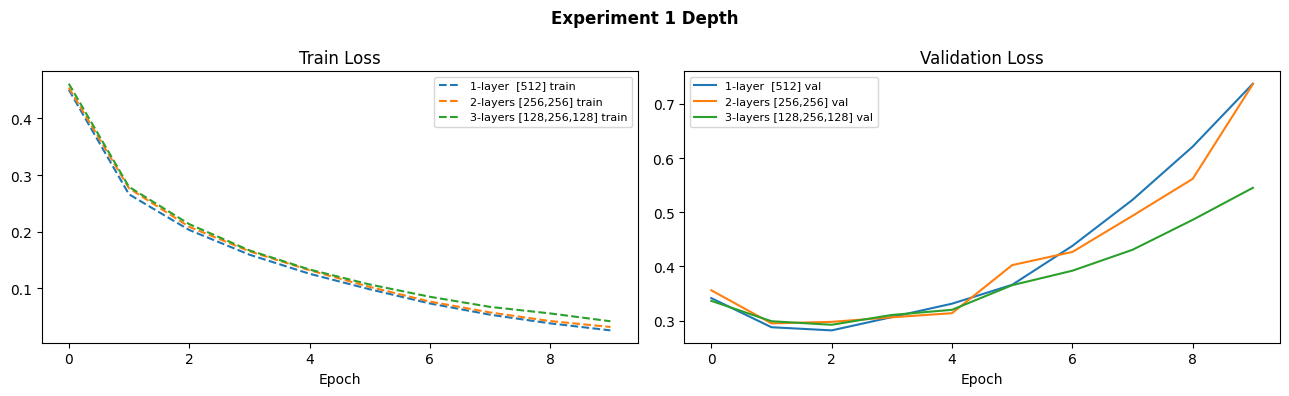

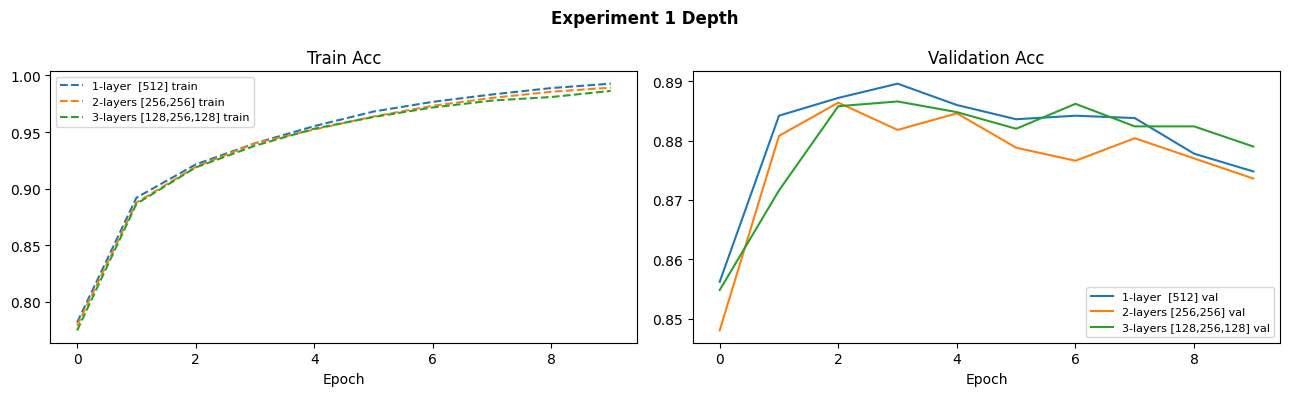


=== Experiment 1 Results ===
                        Best Val Acc  Test Acc     Params
1-layer  [512]                0.8896    0.8860  2627074.0
2-layers [256,256]            0.8864    0.8906  2659330.0
3-layers [128,256,128]        0.8866    0.8903  2642690.0


In [11]:
# Hidden dims chosen to keep param counts roughly equal across configs
depth_configs = {
    '1-layer  [512]':       {'embed_dim': 128, 'hidden_dims': [512],          'dropout': 0.3},
    '2-layers [256,256]':   {'embed_dim': 128, 'hidden_dims': [256, 256],     'dropout': 0.3},
    '3-layers [128,256,128]':{'embed_dim': 128, 'hidden_dims': [128, 256, 128],'dropout': 0.3},
}

# Print param counts before training
print('Param counts:')
for name, cfg in depth_configs.items():
    m = MLPClassifier(len(vocab), cfg['embed_dim'], cfg['hidden_dims'], 2, cfg['dropout'])
    print(f'  {name}: {count_params(m):,}')

depth_histories, depth_results = {}, {}
NUM_EPOCHS = 10

for name, cfg in depth_configs.items():
    print(f'\n── Training: {name} ──')
    hist, best_val, test_acc, n_params = train_model(cfg, num_epochs=NUM_EPOCHS)
    depth_histories[name] = hist
    depth_results[name]   = {'best_val_acc': best_val, 'test_acc': test_acc, 'params': n_params}

plot_curves(depth_histories, metric='loss', title='Experiment 1 Depth')
plot_curves(depth_histories, metric='acc',  title='Experiment 1 Depth')

print('\n=== Experiment 1 Results ===')
df1 = pd.DataFrame(depth_results).T
df1.columns = ['Best Val Acc', 'Test Acc', 'Params']
print(df1.to_string())

## 4. Experiment 2 — Embedding Dimension
Use the best architecture from Experiment 1, vary `d_e ∈ {64, 128, 256}`.

**Controlled variables:** best depth from Exp 1, `dropout=0.3`  
**Variable:** `embed_dim`


── Training: d_e=64 ──
  Epoch 01 | train loss 0.4827 acc 0.7645 | val loss 0.3767 acc 0.8318
  Epoch 02 | train loss 0.3124 acc 0.8690 | val loss 0.3170 acc 0.8664
  Epoch 03 | train loss 0.2387 acc 0.9077 | val loss 0.3036 acc 0.8800
  Epoch 04 | train loss 0.1930 acc 0.9282 | val loss 0.2971 acc 0.8822
  Epoch 05 | train loss 0.1585 acc 0.9448 | val loss 0.3332 acc 0.8820
  Epoch 06 | train loss 0.1300 acc 0.9563 | val loss 0.3613 acc 0.8780
  Epoch 07 | train loss 0.1028 acc 0.9676 | val loss 0.3694 acc 0.8812
  Epoch 08 | train loss 0.0836 acc 0.9737 | val loss 0.4032 acc 0.8794
  Epoch 09 | train loss 0.0660 acc 0.9799 | val loss 0.4305 acc 0.8814
  Epoch 10 | train loss 0.0519 acc 0.9840 | val loss 0.4917 acc 0.8754

── Training: d_e=128 ──
  Epoch 01 | train loss 0.4515 acc 0.7772 | val loss 0.3399 acc 0.8562
  Epoch 02 | train loss 0.2733 acc 0.8894 | val loss 0.2929 acc 0.8800
  Epoch 03 | train loss 0.2044 acc 0.9225 | val loss 0.2810 acc 0.8882
  Epoch 04 | train loss 0.16

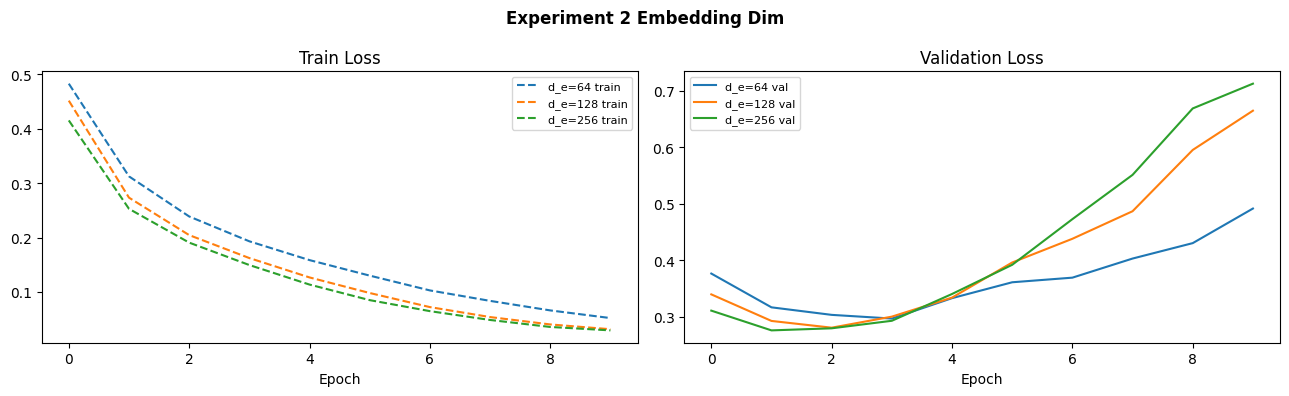

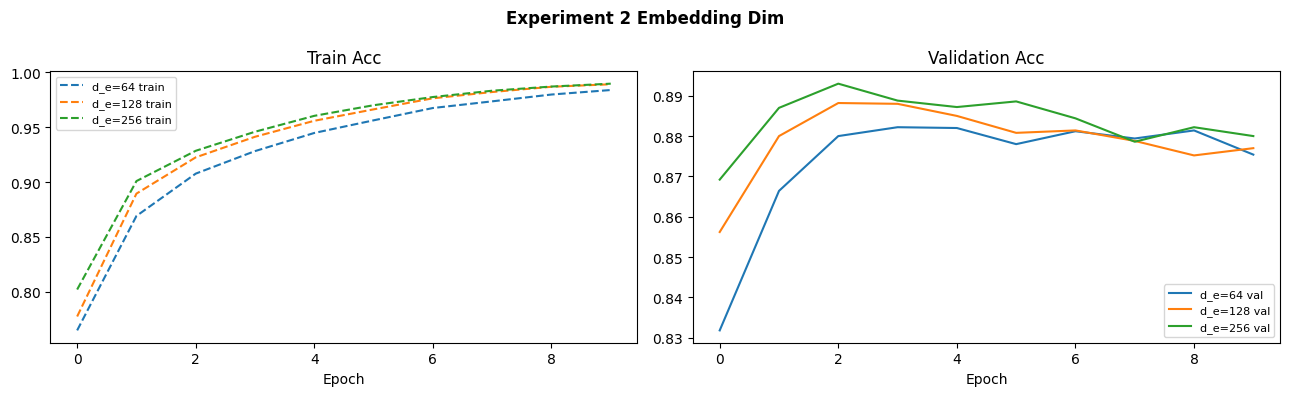


=== Experiment 2 Results ===
         Best Val Acc  Test Acc     Params
d_e=64         0.8822    0.8867  1362946.0
d_e=128        0.8882    0.8906  2659330.0
d_e=256        0.8930    0.8926  5252098.0


In [12]:
# Replace hidden_dims with the winner from Experiment 1
BEST_HIDDEN_DIMS = [256, 256]  # ← update after running Experiment 1

embed_configs = {
    'd_e=64':  {'embed_dim': 64,  'hidden_dims': BEST_HIDDEN_DIMS, 'dropout': 0.3},
    'd_e=128': {'embed_dim': 128, 'hidden_dims': BEST_HIDDEN_DIMS, 'dropout': 0.3},
    'd_e=256': {'embed_dim': 256, 'hidden_dims': BEST_HIDDEN_DIMS, 'dropout': 0.3},
}

embed_histories, embed_results = {}, {}

for name, cfg in embed_configs.items():
    print(f'\n── Training: {name} ──')
    hist, best_val, test_acc, n_params = train_model(cfg, num_epochs=NUM_EPOCHS)
    embed_histories[name] = hist
    embed_results[name]   = {'best_val_acc': best_val, 'test_acc': test_acc, 'params': n_params}

plot_curves(embed_histories, metric='loss', title='Experiment 2 Embedding Dim')
plot_curves(embed_histories, metric='acc',  title='Experiment 2 Embedding Dim')

print('\n=== Experiment 2 Results ===')
df2 = pd.DataFrame(embed_results).T
df2.columns = ['Best Val Acc', 'Test Acc', 'Params']
print(df2.to_string())

## 5. Experiment 3 — Dropout Rate
Use the best architecture and embedding dim from Experiments 1 & 2, vary `p ∈ {0.2, 0.3, 0.5}`.

**Controlled variables:** best depth + best `embed_dim`  
**Variable:** dropout rate


── Training: dropout=0.2 ──
  Epoch 01 | train loss 0.4510 acc 0.7815 | val loss 0.3444 acc 0.8502
  Epoch 02 | train loss 0.2713 acc 0.8897 | val loss 0.2975 acc 0.8746
  Epoch 03 | train loss 0.2050 acc 0.9223 | val loss 0.2860 acc 0.8814
  Epoch 04 | train loss 0.1612 acc 0.9422 | val loss 0.3067 acc 0.8862
  Epoch 05 | train loss 0.1255 acc 0.9565 | val loss 0.3206 acc 0.8872
  Epoch 06 | train loss 0.0983 acc 0.9676 | val loss 0.3869 acc 0.8796
  Epoch 07 | train loss 0.0721 acc 0.9767 | val loss 0.4028 acc 0.8796
  Epoch 08 | train loss 0.0547 acc 0.9827 | val loss 0.4613 acc 0.8784
  Epoch 09 | train loss 0.0379 acc 0.9876 | val loss 0.6111 acc 0.8804
  Epoch 10 | train loss 0.0321 acc 0.9897 | val loss 0.6999 acc 0.8736

── Training: dropout=0.3 ──
  Epoch 01 | train loss 0.4381 acc 0.7905 | val loss 0.3275 acc 0.8626
  Epoch 02 | train loss 0.2707 acc 0.8911 | val loss 0.2915 acc 0.8786
  Epoch 03 | train loss 0.2085 acc 0.9197 | val loss 0.2836 acc 0.8876
  Epoch 04 | train 

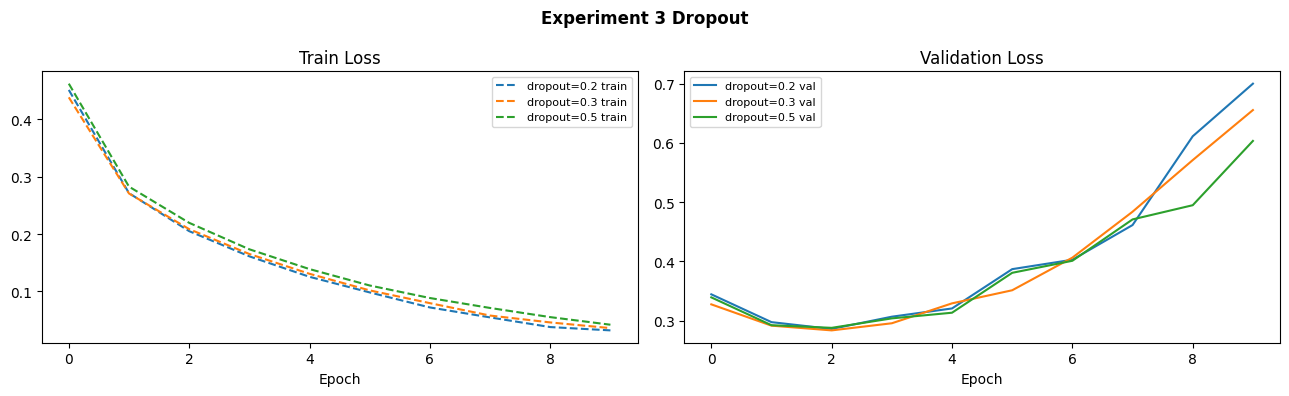

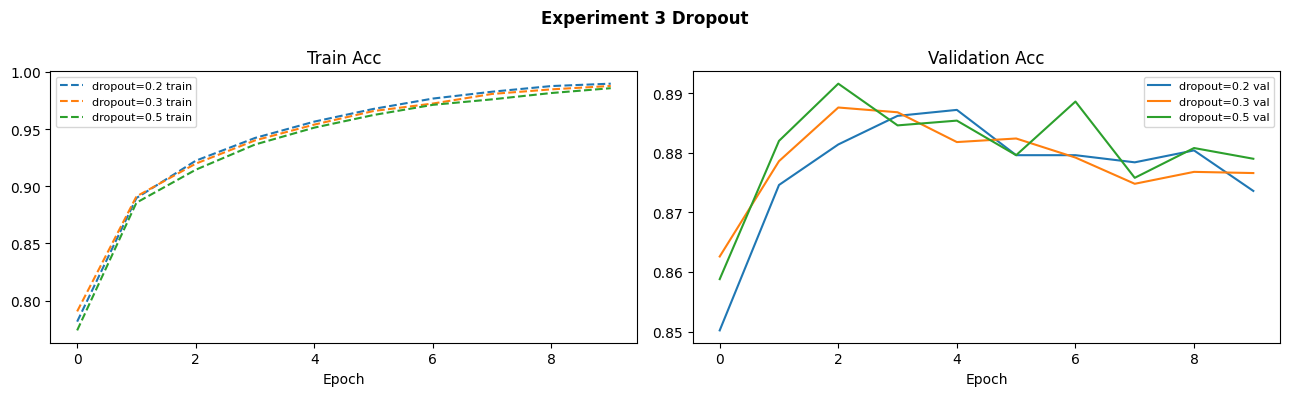


=== Experiment 3 Results ===
             Best Val Acc  Test Acc     Params
dropout=0.2        0.8872    0.8891  2659330.0
dropout=0.3        0.8876    0.8860  2659330.0
dropout=0.5        0.8916    0.8938  2659330.0


In [13]:
BEST_EMBED_DIM = 128  # ← update after running Experiment 2

dropout_configs = {
    'dropout=0.2': {'embed_dim': BEST_EMBED_DIM, 'hidden_dims': BEST_HIDDEN_DIMS, 'dropout': 0.2},
    'dropout=0.3': {'embed_dim': BEST_EMBED_DIM, 'hidden_dims': BEST_HIDDEN_DIMS, 'dropout': 0.3},
    'dropout=0.5': {'embed_dim': BEST_EMBED_DIM, 'hidden_dims': BEST_HIDDEN_DIMS, 'dropout': 0.5},
}

dropout_histories, dropout_results = {}, {}

for name, cfg in dropout_configs.items():
    print(f'\n── Training: {name} ──')
    hist, best_val, test_acc, n_params = train_model(cfg, num_epochs=NUM_EPOCHS)
    dropout_histories[name] = hist
    dropout_results[name]   = {'best_val_acc': best_val, 'test_acc': test_acc, 'params': n_params}

plot_curves(dropout_histories, metric='loss', title='Experiment 3 Dropout')
plot_curves(dropout_histories, metric='acc',  title='Experiment 3 Dropout')

print('\n=== Experiment 3 Results ===')
df3 = pd.DataFrame(dropout_results).T
df3.columns = ['Best Val Acc', 'Test Acc', 'Params']
print(df3.to_string())

## 6. Final Baseline Results Summary

In [15]:
all_results = {
    **{f'[Depth] {k}': v   for k, v in depth_results.items()},
    **{f'[Embed] {k}': v   for k, v in embed_results.items()},
    **{f'[Drop]  {k}': v   for k, v in dropout_results.items()},
}

df_all = pd.DataFrame(all_results).T
df_all.columns = ['Best Val Acc', 'Test Acc', 'Params']
df_all = df_all.sort_values('Best Val Acc', ascending=False)

print('=== All Experiment Results (sorted by Val Acc) ===')
print(df_all.to_string())

best_row = df_all.iloc[0]
print(f'\n→ Best config : {df_all.index[0]}')
print(f'  Val  Acc    : {best_row["Best Val Acc"]:.4f}')
print(f'  Test Acc    : {best_row["Test Acc"]:.4f}')
print(f'  Params      : {int(best_row["Params"]):,}')
print('\nThese numbers form the MLP baseline RNN comparison.')

=== All Experiment Results (sorted by Val Acc) ===
                                Best Val Acc  Test Acc     Params
[Embed] d_e=256                       0.8930    0.8926  5252098.0
[Drop]  dropout=0.5                   0.8916    0.8938  2659330.0
[Depth] 1-layer  [512]                0.8896    0.8860  2627074.0
[Embed] d_e=128                       0.8882    0.8906  2659330.0
[Drop]  dropout=0.3                   0.8876    0.8860  2659330.0
[Drop]  dropout=0.2                   0.8872    0.8891  2659330.0
[Depth] 3-layers [128,256,128]        0.8866    0.8903  2642690.0
[Depth] 2-layers [256,256]            0.8864    0.8906  2659330.0
[Embed] d_e=64                        0.8822    0.8867  1362946.0

→ Best config : [Embed] d_e=256
  Val  Acc    : 0.8930
  Test Acc    : 0.8926
  Params      : 5,252,098

These numbers form the MLP baseline RNN comparison.
